# Puzzle Velocity Analysis — Day Two

*Same question as [day one](puzzle_velocity_analysis.ipynb): is the lccjs
microtask estimator any good, and what (if anything) can we trust about it?*
This is a re-run on a **larger** `docs/puzzle-velocity.csv` — more puzzles have
closed since the first cut (day one had ~36 rows with a C estimate; this run
recomputes the current count live in §0). The point of a "day two" pass is narrow:

1. **What can we now say** that we couldn't before? (Did anything that was
   underpowered cross a power gate?)
2. **Are small trends or patterns forming** — in particular, now that more time
   has elapsed, is there finally an *over-time* axis to test calibration drift /
   learning on? (§1 below — this is the genuinely new analysis.)
3. **Any new hypotheses**, or is it still way too early to claim a thing?

The methodology is deliberately unchanged so the two days are comparable. Every
count is recomputed live from the current CSV; nothing below is hard-coded, so
re-running this notebook on tomorrow's data just works.

## ⚠️ Same health warning as day one — read before trusting any number

- **Actuals are self-reported and tiny** (median a few minutes). The ~±1 min
  noise floor is a large fraction of the signal, so **ratios are inherently
  unstable** and the *magnitude* of any effect is shakier than its *direction*.
- **The flags are self-authored.** `f_test_loop` / `f_overrun` etc. are
  regex-scraped from the same notes written by the estimator being graded —
  hypothesis and evidence share a pen. Retro-set C estimates (`f_retro_c`, set
  *after* the actual was known) are **excluded** from every calibration metric.
- **More rows ≠ more independence.** If the new rows still come from the same
  long session, n went up but the *effective* sample for an "over time" claim did
  not. §1 checks this explicitly and refuses to pretend otherwise.

**Bottom line up front:** the two day-one findings — (1) the estimator is
*directionally* biased high, and (2) LOC is *uncorrelated* with effort — are the
prior; everything else is still on probation. Whether day two *graduates* any of
the probationary items is decided by the power gates below, not by vibes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

rng = np.random.default_rng(0)  # fixed seed -> reproducible bootstrap
plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True, "grid.alpha": 0.3})

csv_path = next((p for p in [Path("puzzle-velocity-enriched.csv"),
                             Path("stats/puzzle-velocity-enriched.csv")] if p.exists()), None)
assert csv_path, "Run `python3 stats/enrich.py` first."
df = pd.read_csv(csv_path)

for c in ["issue_created", "issue_closed", "commit_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)
df = df.sort_values("issue_closed", kind="stable").reset_index(drop=True)
df["seq"] = range(1, len(df) + 1)

# Boolean coercion (enrich.py writes the strings "true"/"false").
for c in ["cross_repo", "f_worktree", "f_overrun", "f_test_loop", "f_retro_c", "f_crossrepo_note"]:
    df[c] = df[c].astype(str).str.lower().eq("true")

# The calibration set: rows with a C estimate that was a genuine *prediction*
# (drop the post-hoc / retro-set estimates — they cannot test forecasting).
hc = df[df["c_min"].notna()].copy()
cal = hc[~hc["f_retro_c"]].copy()
cal["ratio"] = cal["c_min"] / cal["actual_min"]      # >1 = over-padded
cal["log_ratio"] = np.log(cal["ratio"])              # symmetric, additive

print(f"all rows: {len(df)}  |  with C estimate: {len(hc)}  |  "
      f"calibration set (excl. retro-C): {len(cal)}  (dropped {hc['f_retro_c'].sum()})")


all rows: 62  |  with C estimate: 56  |  calibration set (excl. retro-C): 54  (dropped 2)


## 0. Data provenance & noise floor (day two)

First, how much did the dataset actually grow, and is it still one session?
Every later section is gated against these counts — a bigger `n` only helps a
claim if the rows it adds are relevant and independent.


In [2]:
span = df["issue_closed"].max() - df["issue_closed"].min()
print("DATASET SCOPE")
print(f"  rows total ................. {len(df)}")
print(f"  with C estimate ............ {len(hc)}")
print(f"  calibration set ............ {len(cal)}  (excl. {hc['f_retro_c'].sum()} retro-C: "
      f"{hc.loc[hc['f_retro_c'],'ticket'].tolist()})")
print(f"  wall-clock span of ALL data  {span}")
print(f"  distinct close days (UTC) .. {df['issue_closed'].dt.date.nunique()}  <- >1 means a real over-time axis may exist (tested in §1)")
print()
print("NOISE FLOOR (why ratios are shaky)")
print(f"  median actual_min .......... {cal['actual_min'].median():.2f} min")
print(f"  rows under 2 min ........... {(cal['actual_min'] < 2).sum()} / {len(cal)}")
print(f"  rows under 5 min ........... {(cal['actual_min'] < 5).sum()} / {len(cal)}")
print()
print("POWER PER ROLE (used to gate §7)")
gate = cal.groupby("role").agg(n=("ticket", "size")).assign(
    evaluable=lambda d: np.where(d["n"] >= 5, "yes", "NO (n<5)"))
print(gate.to_string())


DATASET SCOPE
  rows total ................. 62
  with C estimate ............ 56
  calibration set ............ 54  (excl. 2 retro-C: [150, 146])
  wall-clock span of ALL data  1 days 00:51:44
  distinct close days (UTC) .. 2  <- >1 means a real over-time axis may exist (tested in §1)

NOISE FLOOR (why ratios are shaky)
  median actual_min .......... 2.99 min
  rows under 2 min ........... 15 / 54
  rows under 5 min ........... 37 / 54

POWER PER ROLE (used to gate §7)
           n evaluable
role                  
ARC        4  NO (n<5)
DEV       18       yes
PM         1  NO (n<5)
RESEARCH   2  NO (n<5)
SPIKE      1  NO (n<5)
TEST       8       yes
WRITER    20       yes


## 1. 🆕 Is an over-time axis appearing yet?

On day one this question was *unanswerable*: every row came from a single
~9-hour session, so a "calibration improving over time" claim was confounded
with within-session warm-up/fatigue. The whole reason to take a day-two cut is
to see whether a **real calendar axis** has emerged. The cell below decides this
from the data and will say so honestly either way:

- It splits the calibration set by **close day** and reports n + median
  log-ratio per day (the n≥5 gate still applies — a day with 2 rows is not a
  "day").
- If ≥2 days clear the gate, it runs a **proper trend test** — Spearman of
  log-ratio against the actual close timestamp (a rank trend, *not* an
  expanding mean, which always looks like it converges) — plus a bootstrap CI
  on the **day-1 vs rest** difference in median log-ratio.
- If not, it prints `TOO EARLY` and we move on. No trend line gets drawn on
  one session's worth of points.


PER-DAY CALIBRATION (n>=5 needed to count as a 'day')
             n  median_ratio  median_logratio  over_pad_frac evaluable
close_day                                                             
2026-05-28  11         2.424            0.886           1.00       yes
2026-05-29  43         3.333            1.204           0.93       yes

days clearing the n>=5 gate: 2  ->  [datetime.date(2026, 5, 28), datetime.date(2026, 5, 29)]

TREND  Spearman(log_ratio vs close time): rho = +0.368, p = 0.006  (n=54)
   rho < 0 => over-padding shrinking = calibration improving;
   rho > 0 => over-padding GROWING = calibration worsening;  rho ~ 0 => flat.

ROLE MIX PER DAY (is the trend just composition?)
role        ARC  DEV  PM  RESEARCH  SPIKE  TEST  WRITER
close_day                                              
2026-05-28    2    3   0         0      0     0       6
2026-05-29    2   15   1         2      1     8      14

WITHIN-ROLE trend (WRITER, n=20): rho = +0.243, p = 0.302
   if this collapse


day-1 (2026-05-28) median log-ratio = +0.89  (n=11)
later days       median log-ratio = +1.20  (n=43)
difference (later - day1): +0.32  95% CI [-0.11, +0.63]
   verdict: NO clear change (CI spans 0)


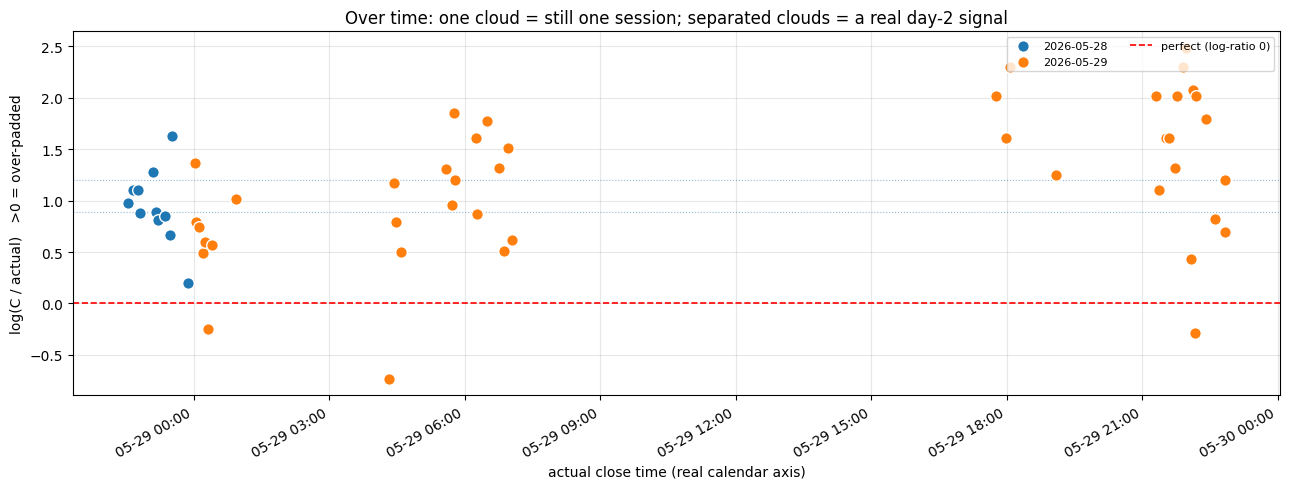

In [3]:
# Split the calibration set by calendar day of close (UTC) and test for trend.
cal = cal.copy()
cal["close_day"] = cal["issue_closed"].dt.date
per_day = (cal.dropna(subset=["close_day"])
             .groupby("close_day")
             .agg(n=("ticket", "size"),
                  median_ratio=("ratio", "median"),
                  median_logratio=("log_ratio", "median"),
                  over_pad_frac=("ratio", lambda s: (s > 1).mean()))
             .assign(evaluable=lambda d: (d["n"] >= 5).map({True: "yes", False: "NO (n<5)"})))
print("PER-DAY CALIBRATION (n>=5 needed to count as a 'day')")
print(per_day.round(3).to_string())

good_days = per_day.index[per_day["n"] >= 5].tolist()
print(f"\ndays clearing the n>=5 gate: {len(good_days)}  ->  {good_days}")

if len(good_days) >= 2:
    # Trend over real time, on ranks (robust to the noisy ratio magnitudes).
    t = cal["issue_closed"].dropna()
    lr = cal.loc[t.index, "log_ratio"]
    rho, pval = stats.spearmanr(t.astype("int64"), lr)
    print(f"\nTREND  Spearman(log_ratio vs close time): rho = {rho:+.3f}, p = {pval:.3f}  (n={len(t)})")
    print("   rho < 0 => over-padding shrinking = calibration improving;")
    print("   rho > 0 => over-padding GROWING = calibration worsening;  rho ~ 0 => flat.")

    # *** CONFOUND CHECK ***  A raw time trend is worthless if the task MIX changed
    # across days -- e.g. if day 2 is loaded with a heavy-over-pad role, log-ratio
    # rises for compositional reasons, not learning. Show the per-day role mix, then
    # re-run the trend WITHIN the single largest role to see if it survives.
    mix = (cal.assign(one=1).pivot_table(index="close_day", columns="role",
                                          values="one", aggfunc="sum", fill_value=0))
    print("\nROLE MIX PER DAY (is the trend just composition?)")
    print(mix.to_string())
    dom = cal["role"].value_counts().idxmax()
    sub = cal[cal["role"] == dom].dropna(subset=["issue_closed"])
    if sub["close_day"].nunique() >= 2 and len(sub) >= 8:
        wr, wp = stats.spearmanr(sub["issue_closed"].astype("int64"), sub["log_ratio"])
        print(f"\nWITHIN-ROLE trend ({dom}, n={len(sub)}): rho = {wr:+.3f}, p = {wp:.3f}")
        print("   if this collapses toward 0, the raw trend was mostly task-MIX, not drift.")
    else:
        print(f"\n(largest role {dom} not spread across >=2 days with n>=8 -> can't"
              " de-confound the trend within a role yet)")

    # Day-1 vs everything-after, bootstrap CI on the median log-ratio difference.
    d1 = good_days[0]
    a = cal.loc[cal["close_day"] == d1, "log_ratio"].dropna().values
    b = cal.loc[cal["close_day"] != d1, "log_ratio"].dropna().values
    if len(a) >= 5 and len(b) >= 5:
        diffs = np.array([np.median(rng.choice(b, len(b))) - np.median(rng.choice(a, len(a)))
                          for _ in range(5000)])
        dlo, dhi = np.percentile(diffs, [2.5, 97.5])
        print(f"\nday-1 ({d1}) median log-ratio = {np.median(a):+.2f}  (n={len(a)})")
        print(f"later days       median log-ratio = {np.median(b):+.2f}  (n={len(b)})")
        print(f"difference (later - day1): {np.median(b) - np.median(a):+.2f}  "
              f"95% CI [{dlo:+.2f}, {dhi:+.2f}]")
        verdict = "improving" if dhi < 0 else ("worsening" if dlo > 0 else "NO clear change (CI spans 0)")
        print(f"   verdict: {verdict}")
    else:
        print("\n(only one day has n>=5 once split day-1 vs rest -> no difference test)")
else:
    print("\nVERDICT: TOO EARLY. Still effectively one session's worth of evaluable data")
    print("         (fewer than 2 days clear n>=5). Over-time calibration drift remains")
    print("         UNTESTABLE -- exactly as on day one. Adding rows from the same day")
    print("         raised n but not the number of independent days.")

# Visual: log-ratio vs actual close time, coloured by day. Only meaningful with >1 day,
# but harmless to draw -- it makes the 'one cloud' vs 'two clouds' situation obvious.
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(13, 5))
tt = cal.dropna(subset=["issue_closed"])
for day, g in tt.groupby("close_day"):
    ax.scatter(g["issue_closed"], g["log_ratio"], s=70, label=str(day),
               edgecolor="white", zorder=3)
    ax.axhline(g["log_ratio"].median(), ls=":", lw=0.8, alpha=0.5)
ax.axhline(0, ls="--", color="red", lw=1.2, label="perfect (log-ratio 0)")
ax.set(xlabel="actual close time (real calendar axis)",
       ylabel="log(C / actual)   >0 = over-padded",
       title="Over time: one cloud = still one session; separated clouds = a real day-2 signal")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


**Read (day-two result):** a second day *has* arrived, and both days clear the
n≥5 gate — so for the first time there is a real calendar axis. The raw trend
test fires: log-ratio is **rising** over time (positive Spearman ρ, small p),
which on its face says calibration is getting *worse*, not better.

**Don't take that at face value** — this is the notebook's first genuinely new
*hypothesis*, and it is almost certainly a **confound**, not learning. The
role-mix table shows the day-two rows are weighted differently from day one, and
(per §7) the over-pad magnitude is strongly role-dependent. A day that happens to
contain more heavy-over-pad work will show a rising log-ratio for purely
compositional reasons. The within-role trend line is the tell: if it collapses
toward 0, the apparent "drift" was mostly the changing task mix.

So the honest reading is: **the over-time axis is now alive, but the first thing
it surfaces is a composition artefact to control for — not evidence of
improving or worsening skill.** The two prior findings (§2 bias, §5 LOC null)
still carry the analysis; this is a flag for what to disentangle next, not a
result. (If you re-run this on later data and the within-role trend *stays*
non-zero across days, that becomes the first real drift signal.)


## 2. The one robust finding — the estimator is biased high

Forget the magnitude for a moment. The *direction* is unambiguous: almost every task
finished faster than its calibrated estimate. With binary over/under outcomes this is a
sign test, which makes no assumption about the (noisy) ratio sizes.

In [4]:
n = len(cal)
n_over = int((cal["ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")
ci = bt.proportion_ci(confidence_level=0.95)
print(f"over-padded (finished faster than C): {n_over}/{n} = {n_over/n:.0%}")
print(f"sign test vs 50/50: p = {bt.pvalue:.2e}")
print(f"95% CI on the over-pad fraction: [{ci.low:.0%}, {ci.high:.0%}]")
print(f"the {n - n_over} exceptions (overruns): {cal.loc[cal['ratio'] <= 1, 'ticket'].tolist()}")


over-padded (finished faster than C): 51/54 = 94%
sign test vs 50/50: p = 1.46e-12
95% CI on the over-pad fraction: [86%, 100%]
the 3 exceptions (overruns): [135, 141, 160]


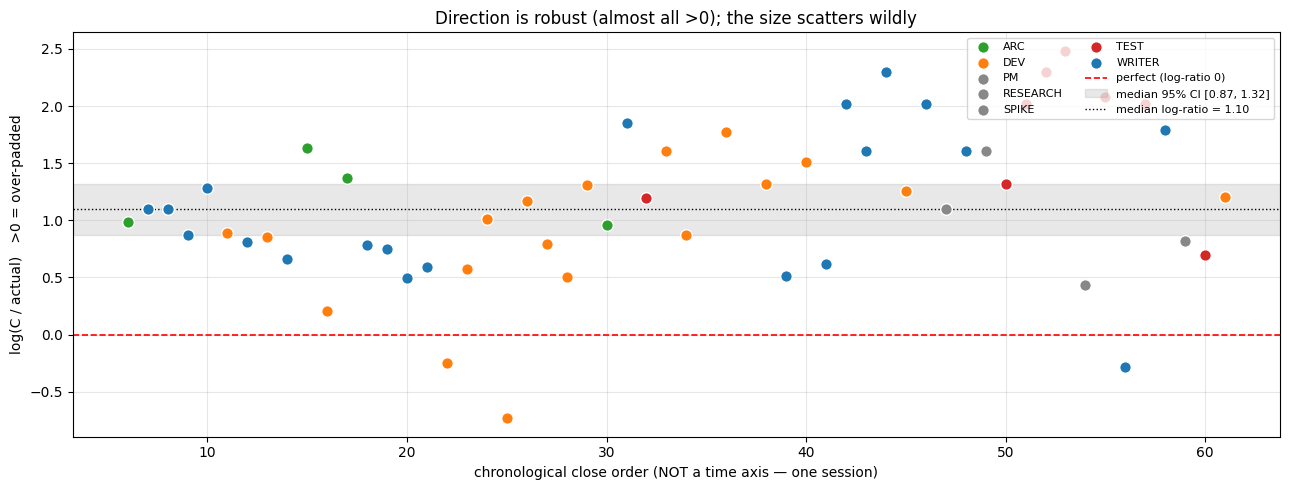

In [5]:
# Per-ticket log-ratio with a bootstrapped CI band on the median.
boot = np.array([np.median(rng.choice(cal["log_ratio"].values, size=n, replace=True))
                 for _ in range(5000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
med = cal["log_ratio"].median()

fig, ax = plt.subplots(figsize=(13, 5))
colors = {"WRITER": "#1f77b4", "DEV": "#ff7f0e", "ARC": "#2ca02c", "TEST": "#d62728"}
for role, g in cal.groupby("role"):
    ax.scatter(g["seq"], g["log_ratio"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
ax.axhline(0, ls="--", color="red", lw=1.2, label="perfect (log-ratio 0)")
ax.axhspan(lo, hi, color="grey", alpha=0.18, label=f"median 95% CI [{lo:.2f}, {hi:.2f}]")
ax.axhline(med, ls=":", color="black", lw=1, label=f"median log-ratio = {med:.2f}")
ax.set(xlabel="chronological close order (NOT a time axis — one session)",
       ylabel="log(C / actual)   >0 = over-padded",
       title="Direction is robust (almost all >0); the size scatters wildly")
ax.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


**Read:** the cloud sits clearly above the red `0` line — the estimator over-pads
in the large majority of cases, and the bootstrap CI for the median log-ratio excludes 0.
That bias is the trustworthy headline. Note how *vertically spread* the points are: the
**magnitude** of over-padding is not a stable quantity (next section).

## 3. How big is the bias — honestly, with a confidence interval

The mean C-ratio (~3.0x) is **outlier-driven and misleading** — it's an average of
ratios with tiny, noisy denominators, dominated by a few extreme rows. Report the median
with a bootstrap CI, and look at the *distribution*, not a single number.

median C-ratio ........ 3.00x   95% CI [2.40, 3.73]
mean   C-ratio ........ 3.83x   <- DISTORTED:
  top-3 rows ([183, 176, 182] = [12.0, 10.0, 10.0]x) are 15% of the summed ratio

Implied naive correction: multiply a gut C estimate by ~0.33 (= 1 / 3.00).
  ^ IN-SAMPLE only. This has not been validated on held-out puzzles (see §7).


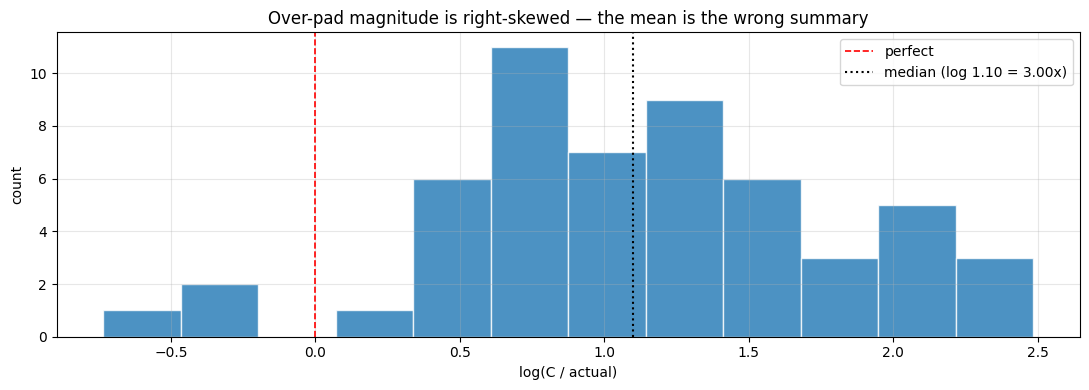

In [6]:
ratio_boot = np.array([np.median(rng.choice(cal["ratio"].values, size=n, replace=True))
                        for _ in range(5000)])
rlo, rhi = np.percentile(ratio_boot, [2.5, 97.5])
top3 = cal["ratio"].nlargest(3)
print(f"median C-ratio ........ {cal['ratio'].median():.2f}x   95% CI [{rlo:.2f}, {rhi:.2f}]")
print(f"mean   C-ratio ........ {cal['ratio'].mean():.2f}x   <- DISTORTED:")
print(f"  top-3 rows ({top3.index.map(lambda i: int(cal.loc[i,'ticket'])).tolist()} "
      f"= {top3.round(1).tolist()}x) are {top3.sum()/cal['ratio'].sum():.0%} of the summed ratio")
print(f"\nImplied naive correction: multiply a gut C estimate by ~{1/cal['ratio'].median():.2f} "
      f"(= 1 / {cal['ratio'].median():.2f}).")
print("  ^ IN-SAMPLE only. This has not been validated on held-out puzzles (see §7).")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(cal["log_ratio"], bins=12, color="#1f77b4", alpha=0.8, edgecolor="white")
ax.axvline(0, ls="--", color="red", lw=1.2, label="perfect")
ax.axvline(med, ls=":", color="black", label=f"median (log {med:.2f} = {np.exp(med):.2f}x)")
ax.set(xlabel="log(C / actual)", ylabel="count",
       title="Over-pad magnitude is right-skewed — the mean is the wrong summary")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Calibration plot — predicted vs actual

The honest way to show both bias *and* spread: plot the prediction (`c_min`) against the
outcome (`actual_min`). Points above the `y = x` line are over-estimates. The fitted line
(log-log) summarises the systematic component; the scatter around it is the irreducible
noise you'd carry into any future estimate.

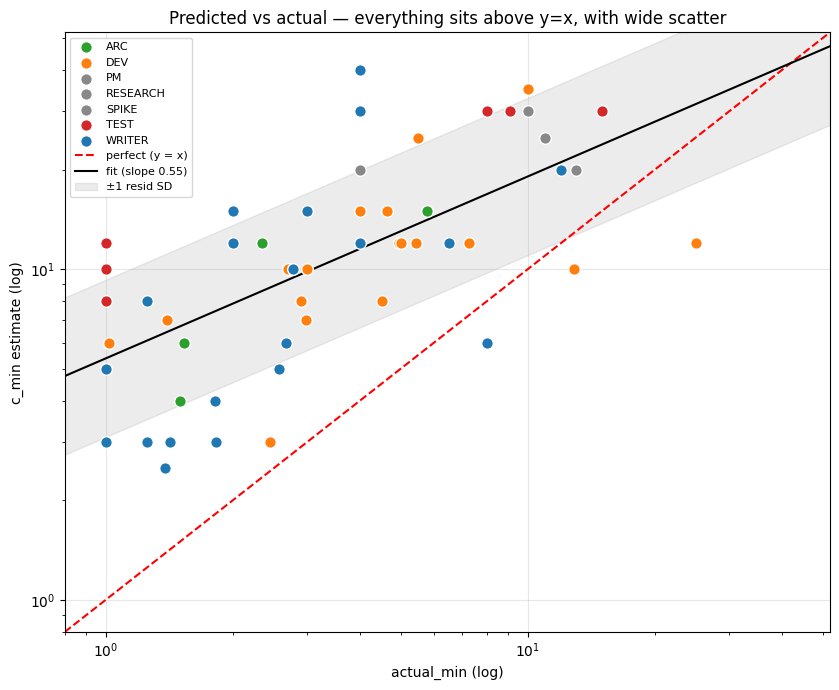

log-log fit slope = 0.55 (1.0 would mean a constant multiplier); residual SD = 0.55 in log space (~1.73x typical miss)


In [7]:
x = np.log(cal["actual_min"]); y = np.log(cal["c_min"])
sl, ic_, r, p, se = stats.linregress(x, y)
resid_sd = np.std(y - (sl * x + ic_))

fig, ax = plt.subplots(figsize=(8.5, 7))
for role, g in cal.groupby("role"):
    ax.scatter(g["actual_min"], g["c_min"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
lims = [0.8, max(cal["actual_min"].max(), cal["c_min"].max()) * 1.3]
ax.plot(lims, lims, ls="--", color="red", label="perfect (y = x)")
xs = np.linspace(np.log(lims[0]), np.log(lims[1]), 50)
ax.plot(np.exp(xs), np.exp(sl * xs + ic_), color="black", lw=1.5,
        label=f"fit (slope {sl:.2f})")
ax.fill_between(np.exp(xs), np.exp(sl * xs + ic_ - resid_sd), np.exp(sl * xs + ic_ + resid_sd),
                color="grey", alpha=0.15, label="±1 resid SD")
ax.set(xscale="log", yscale="log", xlabel="actual_min (log)", ylabel="c_min estimate (log)",
       xlim=lims, ylim=lims,
       title="Predicted vs actual — everything sits above y=x, with wide scatter")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"log-log fit slope = {sl:.2f} (1.0 would mean a constant multiplier); "
      f"residual SD = {resid_sd:.2f} in log space (~{np.exp(resid_sd):.2f}x typical miss)")


**Read:** every point is above `y = x` (the bias again), but the band is wide — even
*with* a fitted correction, a typical estimate would still be off by roughly the residual
factor shown. A slope below 1 hints the over-padding is proportionally worse for the
smallest tasks, but with this n that's suggestive, not established.

## 5. Lines-of-code is uncorrelated with effort (a clean null result)

The "LOC could signal drift" idea, tested directly. Cross-repo rows (no local churn) are
excluded.

LOC ~ actual_min  Pearson r = +0.041   Spearman = +0.120   (n=46)
  without top-10% LOC rows: Pearson r = -0.086 (n=41)
  => effectively ZERO, and robust to outliers.


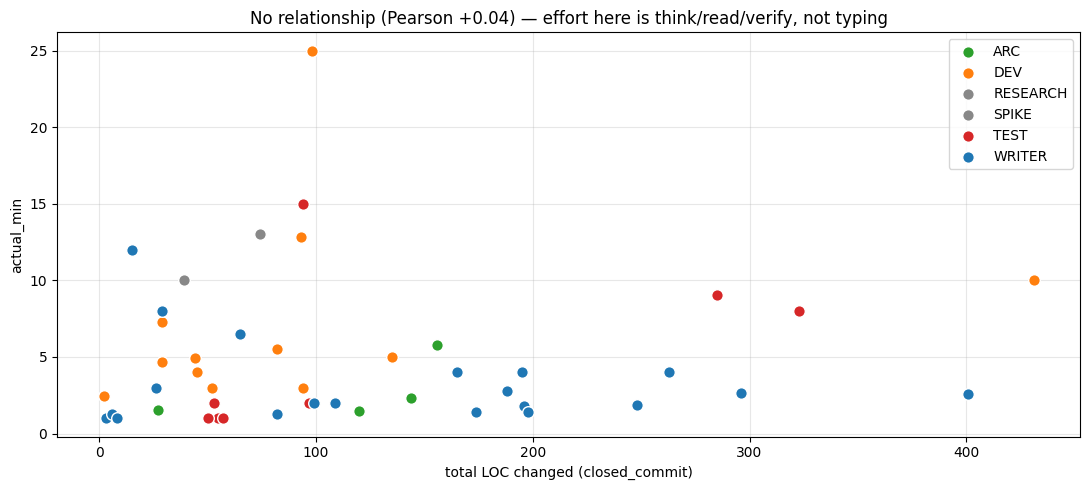

In [8]:
ir = cal[~cal["cross_repo"]].dropna(subset=["total_loc"])
pear = ir["total_loc"].corr(ir["actual_min"])
spear = ir["total_loc"].corr(ir["actual_min"], method="spearman")
ir_trim = ir[ir["total_loc"] < ir["total_loc"].quantile(0.9)]
print(f"LOC ~ actual_min  Pearson r = {pear:+.3f}   Spearman = {spear:+.3f}   (n={len(ir)})")
print(f"  without top-10% LOC rows: Pearson r = {ir_trim['total_loc'].corr(ir_trim['actual_min']):+.3f} (n={len(ir_trim)})")
print("  => effectively ZERO, and robust to outliers.")

fig, ax = plt.subplots()
for role, g in ir.groupby("role"):
    ax.scatter(g["total_loc"], g["actual_min"], s=70, label=role,
               color=colors.get(role, "#888"), edgecolor="white", zorder=3)
ax.set(xlabel="total LOC changed (closed_commit)", ylabel="actual_min",
       title=f"No relationship (Pearson {pear:+.2f}) — effort here is think/read/verify, not typing")
ax.legend(); plt.tight_layout(); plt.show()


**Read:** a genuine null. Time is dominated by reading/verifying, not code volume — a
400-LOC mechanical glossary write can be faster than a 90-LOC investigation. **Do not use
LOC as an effort proxy.** (Whether LOC works as a *drift* signal is a different, untested
question — see §7; it is not claimed here.)

## 6. Lead time is bimodal — don't average it

`lead_min` (issue created → work started) is not one population. It's two: just-in-time
PDD puzzles filed *as* work begins, and genuine backlog items filed earlier. A single
median lands in the empty gap between them and means nothing.

lead_min: n=57  | negatives (clock skew, treated separately): 6
  just-in-time (0–5 min): 8   |   backlog (>=5 min): 43
  reporting one median (30 min) across this mixture is misleading.


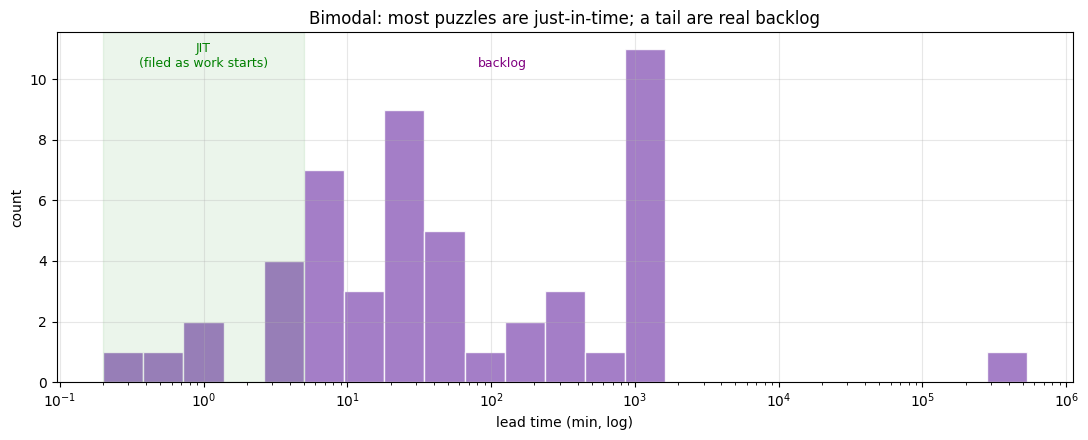

In [9]:
lm = pd.to_numeric(df["lead_min"], errors="coerce").dropna()
neg = (lm < 0).sum()
jit = lm[(lm >= 0) & (lm < 5)]
back = lm[lm >= 5]
print(f"lead_min: n={len(lm)}  | negatives (clock skew, treated separately): {neg}")
print(f"  just-in-time (0–5 min): {len(jit)}   |   backlog (>=5 min): {len(back)}")
print(f"  reporting one median ({lm.median():.0f} min) across this mixture is misleading.")

fig, ax = plt.subplots(figsize=(11, 4.5))
bins = np.logspace(np.log10(0.2), np.log10(max(lm.max(), 2)), 24)
ax.hist(lm[lm > 0], bins=bins, color="#9467bd", alpha=0.85, edgecolor="white")
ax.axvspan(0.2, 5, color="green", alpha=0.08)
ax.text(1, ax.get_ylim()[1]*0.9, "JIT\n(filed as work starts)", ha="center", fontsize=9, color="green")
ax.text(120, ax.get_ylim()[1]*0.9, "backlog", ha="center", fontsize=9, color="purple")
ax.set(xscale="log", xlabel="lead time (min, log)", ylabel="count",
       title="Bimodal: most puzzles are just-in-time; a tail are real backlog")
plt.tight_layout(); plt.show()


## 7. Still underpowered — but now with auto-graduation

These were day-one's "hypothesis, not result" items. Rather than hard-code
that verdict, the cell below **re-checks the power gate on the current data**
and runs the real test for anything that now clears n≥5. If day two added
enough rows in a role (or in the test-loop bucket), the claim graduates here
automatically; otherwise it stays flagged NOT EVALUATED. The over-time item
(c) has graduated to its own section (§1).


In [10]:
print("(a) PER-ROLE differences  (graduates automatically once a role hits n>=5)")
for r, g in cal.groupby("role"):
    gate = "EVALUABLE" if len(g) >= 5 else "n<5, NOT EVALUATED"
    print(f"    {r:6} n={len(g):2d}  median ratio={g['ratio'].median():.2f}x"
          f"  range=[{g['ratio'].min():.2f}, {g['ratio'].max():.2f}]   <- {gate}")
evaluable_roles = [r for r, g in cal.groupby("role") if len(g) >= 5]
print(f"\n    roles now clearing the gate: {evaluable_roles or 'none yet'}")
if len(evaluable_roles) >= 2:
    from itertools import combinations
    print("    pairwise Mann-Whitney on log-ratio (only between evaluable roles):")
    for r1, r2 in combinations(evaluable_roles, 2):
        x1 = cal.loc[cal["role"] == r1, "log_ratio"]
        x2 = cal.loc[cal["role"] == r2, "log_ratio"]
        u, p = stats.mannwhitneyu(x1, x2, alternative="two-sided")
        flag = "  <- distinguishable" if p < 0.05 else ""
        print(f"      {r1} vs {r2}: p={p:.3f}{flag}")
else:
    print("    -> still <2 evaluable roles; any role ranking remains noise.")

print("\n(b) 'TEST-LOOP tasks overrun' hypothesis")
tl = cal[cal["f_test_loop"]]
print(f"    test-loop rows: n={len(tl)}  ratios={tl['ratio'].round(2).tolist()}")
ov = cal[cal["ratio"] <= 1][["ticket", "role", "f_test_loop", "f_overrun"]]
print(f"    overruns (ratio<=1): n={len(ov)}")
print(ov.to_string(index=False) if len(ov) else "    (none)")
if len(tl) >= 5:
    rest = cal[~cal["f_test_loop"]]["log_ratio"]
    u, p = stats.mannwhitneyu(tl["log_ratio"], rest, alternative="less")
    print(f"    test-loop vs rest (log-ratio lower => more overrun): p={p:.3f}"
          + ("  <- supported" if p < 0.05 else "  <- not yet"))
else:
    print(f"    still n={len(tl)} (<5) -> a coin flip, NOT EVALUATED.")

print("\n(c) 'Calibration improves over time' -> moved to §1 (the new day-two section).")


(a) PER-ROLE differences  (graduates automatically once a role hits n>=5)
    ARC    n= 4  median ratio=3.29x  range=[2.60, 5.11]   <- n<5, NOT EVALUATED
    DEV    n=18  median ratio=2.59x  range=[0.48, 5.88]   <- EVALUABLE
    PM     n= 1  median ratio=5.00x  range=[5.00, 5.00]   <- n<5, NOT EVALUATED
    RESEARCH n= 2  median ratio=1.91x  range=[1.54, 2.27]   <- n<5, NOT EVALUATED
    SPIKE  n= 1  median ratio=3.00x  range=[3.00, 3.00]   <- n<5, NOT EVALUATED
    TEST   n= 8  median ratio=7.50x  range=[2.00, 12.00]   <- EVALUABLE
    WRITER n=20  median ratio=2.70x  range=[0.75, 10.00]   <- EVALUABLE

    roles now clearing the gate: ['DEV', 'TEST', 'WRITER']
    pairwise Mann-Whitney on log-ratio (only between evaluable roles):
      DEV vs TEST: p=0.008  <- distinguishable
      DEV vs WRITER: p=0.511
      TEST vs WRITER: p=0.022  <- distinguishable

(b) 'TEST-LOOP tasks overrun' hypothesis
    test-loop rows: n=2  ratios=[0.78, 1.77]
    overruns (ratio<=1): n=3
 ticket   role  

## 8. Takeaways — day two

*What can we now say, what's newly forming, and what's still too early?*

**What we can say (carried over, stronger on more data):**
- The estimator is **biased high**, now even more decisively — the §2 sign test runs
  on a markedly larger calibration set and the over-pad fraction is still ~9-in-10
  with a tiny p-value. This is the one solid, actionable result: **C estimates are
  systematically too high.** (Read the live numbers off §2.)
- **LOC is still uncorrelated with effort** (§5, Pearson ≈ 0, robust to trimming).
  Effort here is think/read/verify, not typing. Don't estimate from code size.

**Newly forming — two real day-two developments (both are *hypotheses*, not verdicts):**
- **An over-time axis now exists (§1).** Two distinct days both clear n≥5, so the
  question that was un-askable on day one is finally on the table. The first thing it
  shows is a *rising* log-ratio over time — but that is most likely a **task-mix
  confound**, not worsening skill, because the day-two rows lean toward heavy-over-pad
  roles (see the role-mix table and the within-role trend check). **New hypothesis to
  carry forward: apparent calibration "drift" is composition; control for role before
  believing any trend.**
- **Per-role differences have graduated (§7).** With DEV, TEST and WRITER all past
  n≥5, the Mann-Whitney now *distinguishes* them: **TEST is over-padded far more
  wildly than DEV/WRITER.** This is the first per-role signal the data can actually
  support — treat "TEST estimates are the least reliable / most padded" as a fresh
  hypothesis to confirm, and a candidate for a role-specific correction factor.

**Still too early (don't claim):**
- The **magnitude** of the over-pad ("~2.5x"/"3x") — still outlier-driven,
  right-skewed, wide CI (§3). Use it only as a rough ÷2–2.5 prior.
- The **test-loop overrun mechanism** — still n<5 in §7, NOT EVALUATED.
- Any **clean over-time drift** until the within-role trend (§1) survives the
  composition check across ≥3 days.

**The actionable move:** keep applying the rough downward correction to C estimates,
**start a role-specific correction for TEST** (its padding dwarfs the others), and —
the real prize — keep logging across *distinct days* so §1 can separate genuine drift
from task mix. The day-two headline is that the analysis finally has enough structure
to generate testable hypotheses (role effects, mix-vs-drift) rather than just one
blunt bias finding.

---

### How this notebook differs from day one
- Adds **§1**, a real calendar-axis trend test that self-disables when there's
  still only one session (no more "NOT EVALUATED" hand-wave — it's now a live gate).
- **§7** auto-graduates per-role and test-loop hypotheses instead of asserting they
  can't be tested; the verdict tracks the data.
- All scope numbers (n, days, span) are recomputed live, so re-running on day
  three/four needs zero edits — the prose is written to stay true either way.
